# Customer Segmentation Analysis and Prediction

## 1. Introduction

This Jupyter notebook presents a comprehensive machine learning pipeline for customer segmentation. The goal is to classify customers into predefined segments ('A', 'B', 'C', 'D') based on their demographic and behavioral attributes. Customer segmentation is a vital strategy for businesses to understand their diverse customer base, enabling tailored marketing campaigns, personalized product recommendations, and improved customer satisfaction.

The dataset contains various customer attributes such as Gender, Age, Marital Status, Education, Profession, Work Experience, Spending Score, Family Size, and an anonymous categorical variable `Var_1`. We will perform exploratory data analysis, data preprocessing, model training, evaluation, and interpret the results to gain insights into the customer segments.

**Problem Type:** Multi-class Classification.
**Target Variable:** `Segmentation`

## Architecture Diagram (Conceptual)

*(Note: As an AI, I cannot generate an SVG file directly. This section describes the conceptual architecture that would typically be represented in a diagram like one from diagrams.net.)*

**Conceptual Data Science Pipeline for Customer Segmentation**

1.  **Data Ingestion Layer:**
    *   **Source:** `customer_segmentation.csv` (CSV File)
    *   **Tool:** Pandas for loading.

2.  **Data Preprocessing Layer:**
    *   **Components:**
        *   **Missing Value Imputation:** Strategies like mean/median for numerical, mode for categorical.
        *   **Feature Engineering:** Creating new features or transforming existing ones (e.g., binning Age, interaction terms).
        *   **Categorical Encoding:** One-Hot Encoding for nominal, Label Encoding for ordinal.
        *   **Numerical Scaling:** Standardization (StandardScaler).
        *   **Outlier Handling:** (Optional, depending on EDA findings).
    *   **Tool:** Scikit-learn's `SimpleImputer`, `OneHotEncoder`, `StandardScaler`, `ColumnTransformer`, `Pipeline`.

3.  **Model Training Layer:**
    *   **Components:**
        *   **Data Split:** Train-test split (e.g., 80/20 ratio, stratified).
        *   **Model Selection:** Logistic Regression, Random Forest, Gradient Boosting, SVM.
        *   **Hyperparameter Tuning:** GridSearchCV or RandomizedSearchCV for optimal model parameters.
        *   **Cross-Validation:** To ensure model robustness.
    *   **Tool:** Scikit-learn's `train_test_split`, `LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier`, `SVC`, `GridSearchCV`.

4.  **Model Evaluation Layer:**
    *   **Metrics:** Accuracy, Precision, Recall, F1-score, Confusion Matrix (for multi-class classification).
    *   **Tools:** Scikit-learn's `accuracy_score`, `classification_report`, `confusion_matrix`.
    *   **Visualization:** Matplotlib, Seaborn for plots of metrics and confusion matrices.

5.  **Prediction and Deployment Layer (Conceptual for production):**
    *   **Components:**
        *   **API Endpoint:** For real-time predictions.
        *   **Batch Prediction:** For scoring new datasets periodically.
        *   **Model Persistence:** Saving the trained model (e.g., using `joblib` or `pickle`).
    *   **Tools:** Flask/Django (for API), cloud services (AWS SageMaker, Azure ML).

**Flow:** Raw CSV data flows into preprocessing, then into model training, which is iteratively refined by evaluation. The final model is then used for making predictions.


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.svm import SVC
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set a random seed for reproducibility
np.random.seed(42)

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100


## 2. Data Loading

We will load the customer segmentation dataset from a CSV file. For the purpose of this notebook, we assume the dataset is available as 'customer_segmentation.csv' in the same directory.


In [6]:
# Load the dataset
# try:
#     df = pd.read_csv(r'C:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\data\customer_segmentation.csv')
#     print("Dataset loaded successfully.")
# except FileNotFoundError:
#     print("Error: 'customer_segmentation.csv' not found. Creating a dummy dataset based on sample data.")
#     # If the file is not found, create a dummy DataFrame from the sample data
#     sample_data = [
#         {'ID': 462809, 'Gender': 'Male', 'Ever_Married': 'No', 'Age': 22, 'Graduated': 'No', 'Profession': 'Healthcare', 'Work_Experience': 1.0, 'Spending_Score': 'Low', 'Family_Size': 4.0, 'Var_1': 'Cat_4', 'Segmentation': 'D'},
#         {'ID': 462643, 'Gender': 'Female', 'Ever_Married': 'Yes', 'Age': 38, 'Graduated': 'Yes', 'Profession': 'Engineer', 'Work_Experience': np.nan, 'Spending_Score': 'Average', 'Family_Size': 3.0, 'Var_1': 'Cat_4', 'Segmentation': 'A'},
#         {'ID': 466315, 'Gender': 'Female', 'Ever_Married': 'Yes', 'Age': 67, 'Graduated': 'Yes', 'Profession': 'Engineer', 'Work_Experience': 1.0, 'Spending_Score': 'Low', 'Family_Size': 1.0, 'Var_1': 'Cat_6', 'Segmentation': 'B'},
#         {'ID': 461735, 'Gender': 'Male', 'Ever_Married': 'Yes', 'Age': 67, 'Graduated': 'Yes', 'Profession': 'Lawyer', 'Work_Experience': 0.0, 'Spending_Score': 'High', 'Family_Size': 2.0, 'Var_1': 'Cat_6', 'Segmentation': 'B'},
#         {'ID': 462669, 'Gender': 'Female', 'Ever_Married': 'Yes', 'Age': 40, 'Graduated': 'Yes', 'Profession': 'Entertainment', 'Work_Experience': np.nan, 'Spending_Score': 'High', 'Family_Size': 6.0, 'Var_1': 'Cat_6', 'Segmentation': 'A'},
#         {'ID': 461319, 'Gender': 'Male', 'Ever_Married': 'Yes', 'Age': 56, 'Graduated': 'No', 'Profession': 'Artist', 'Work_Experience': 0.0, 'Spending_Score': 'Average', 'Family_Size': 2.0, 'Var_1': 'Cat_6', 'Segmentation': 'C'},
#         {'ID': 460156, 'Gender': 'Male', 'Ever_Married': 'No', 'Age': 32, 'Graduated': 'Yes', 'Profession': 'Healthcare', 'Work_Experience': 1.0, 'Spending_Score': 'Low', 'Family_Size': 3.0, 'Var_1': 'Cat_6', 'Segmentation': 'C'},
#         {'ID': 464347, 'Gender': 'Female', 'Ever_Married': 'No', 'Age': 33, 'Graduated': 'Yes', 'Profession': 'Healthcare', 'Work_Experience': 1.0, 'Spending_Score': 'Low', 'Family_Size': 3.0, 'Var_1': 'Cat_6', 'Segmentation': 'D'},
#         {'ID': 465015, 'Gender': 'Female', 'Ever_Married': 'Yes', 'Age': 61, 'Graduated': 'Yes', 'Profession': 'Engineer', 'Work_Experience': 0.0, 'Spending_Score': 'Low', 'Family_Size': 3.0, 'Var_1': 'Cat_7', 'Segmentation': 'D'},
#         {'ID': 465176, 'Gender': 'Female', 'Ever_Married': 'Yes', 'Age': 55, 'Graduated': 'Yes', 'Profession': 'Artist', 'Work_Experience': 1.0, 'Spending_Score': 'Average', 'Family_Size': 4.0, 'Var_1': 'Cat_6', 'Segmentation': 'C'}
#     ]
#     df = pd.DataFrame(sample_data)
#     print("Using a dummy dataset for demonstration purposes.")


# # Display the first few rows of the dataset
# print("\nFirst 5 rows of the dataset:")
# print(df.head())

# # Display basic information about the dataset
# print("\nDataset Info:")
# print(df.info())

# # Display the shape of the dataset
# print(f"\nDataset has {df.shape[0]} rows and {df.shape[1]} columns.")

df = pd.read_csv(r'C:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\data\customer_segmentation.csv')

print("Dataset loaded successfully.")
print(df.head())

Dataset loaded successfully.
       ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare              1.0   
1  462643  Female          Yes   38       Yes       Engineer              NaN   
2  466315  Female          Yes   67       Yes       Engineer              1.0   
3  461735    Male          Yes   67       Yes         Lawyer              0.0   
4  462669  Female          Yes   40       Yes  Entertainment              NaN   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low          4.0  Cat_4            D  
1        Average          3.0  Cat_4            A  
2            Low          1.0  Cat_6            B  
3           High          2.0  Cat_6            B  
4           High          6.0  Cat_6            A  


## 3. Exploratory Data Analysis (EDA)

EDA is crucial to understand the dataset's characteristics, identify patterns, and prepare the data for modeling. We will examine data types, missing values, unique values in categorical columns, and descriptive statistics for numerical columns.


In [8]:
# Check for missing values
print("\nMissing values before imputation:")
print(df.isnull().sum())
print("\nPercentage of missing values:")
print((df.isnull().sum() / len(df)) * 100)

# Check unique values for categorical columns
print("\nUnique values in categorical columns:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values - {df[col].unique()}")

# Describe numerical columns
print("\nDescriptive statistics for numerical columns:")
print(df.describe())

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'ID' from numerical_cols if present as it's an identifier
if 'ID' in numerical_cols:
    numerical_cols.remove('ID')
if 'Segmentation' in categorical_cols:
    categorical_cols.remove('Segmentation') # Target variable

print(f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Handle missing values
# Impute 'Work_Experience' and 'Family_Size' with their respective medians
# Impute 'Var_1' with the mode (most frequent category)

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

# Impute numerical columns
for col in ['Work_Experience', 'Family_Size']:
    if col in df.columns:
        df[col] = imputer_num.fit_transform(df[[col]]).ravel()

# Impute categorical columns (specifically Var_1)
if 'Var_1' in df.columns:
    df['Var_1'] = imputer_cat.fit_transform(df[['Var_1']]).ravel()

# After imputation, recheck missing values
print("\nMissing values after imputation:")
print(df.isnull().sum())

# Check target variable distribution
print("\nDistribution of Segmentation:")
print(df['Segmentation'].value_counts())
print("\nPercentage distribution of Segmentation:")
print(df['Segmentation'].value_counts(normalize=True) * 100)



Missing values before imputation:
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience      0
Spending_Score       0
Family_Size          0
Var_1               76
Segmentation         0
dtype: int64

Percentage of missing values:
ID                 0.000000
Gender             0.000000
Ever_Married       1.735250
Age                0.000000
Graduated          0.966782
Profession         1.536936
Work_Experience    0.000000
Spending_Score     0.000000
Family_Size        0.000000
Var_1              0.941993
Segmentation       0.000000
dtype: float64

Unique values in categorical columns:
Gender: 2 unique values - ['Male' 'Female']
Ever_Married: 2 unique values - ['No' 'Yes' nan]
Graduated: 2 unique values - ['No' 'Yes' nan]
Profession: 9 unique values - ['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing' nan]
Spending_Score: 3 unique va

### EDA Summary:
*   The dataset contains a mix of numerical and categorical features.
*   `ID` is a unique identifier and should be dropped for modeling.
*   `Work_Experience`, `Family_Size`, and `Var_1` had missing values, which have been imputed using median for numerical and mode for categorical.
*   The `Segmentation` target variable appears to have a relatively balanced distribution, which is good for multi-class classification, but we will keep an eye on it.
*   Categorical features like `Gender`, `Ever_Married`, `Graduated`, `Profession`, `Spending_Score`, and `Var_1` need encoding.

## 4. Preprocessing

Data preprocessing involves transforming raw data into a suitable format for machine learning models. This includes:
*   Dropping irrelevant columns (`ID`).
*   Encoding categorical features.
*   Scaling numerical features.


In [11]:
# Drop 'ID' column as it's an identifier and not useful for modeling
df_processed = df.drop('ID', axis=1)

# Separate features (X) and target (y)
X = df_processed.drop('Segmentation', axis=1)
y = df_processed['Segmentation']

# Identify column types for preprocessing pipelines
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Features for preprocessing: {X.columns.tolist()}")
print(f"Numerical features to scale: {numeric_features}")
print(f"Categorical features to encode: {categorical_features}")

# Create preprocessing pipelines for numerical and categorical features
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Scale numerical features
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-Hot Encode categorical features
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
onehot_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(onehot_features)

# Convert processed features back to a DataFrame for better inspection (optional, good for EDA, but pipeline usually takes numpy array)
X_processed_df = pd.DataFrame(X_processed.toarray(), columns=all_feature_names)
print("\nProcessed features (first 5 rows):")
print(X_processed_df.head())
print(f"\nShape of processed features: {X_processed.shape}")

# Encode the target variable (Segmentation)
# Label Encoding is suitable for target variables in classification
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"\nEncoded target variable classes: {label_encoder.classes_}")
print(f"First 5 encoded target values: {y_encoded[:5]}")


Features for preprocessing: ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']
Numerical features to scale: ['Age', 'Work_Experience', 'Family_Size']
Categorical features to encode: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

Processed features (first 5 rows):
        Age  Work_Experience  Family_Size  Gender_Female  Gender_Male  \
0 -1.284623        -0.451136     0.762698            0.0          1.0   
1 -0.327151        -0.451136     0.095802            1.0          0.0   
2  1.408268        -0.451136    -1.237990            1.0          0.0   
3  1.408268        -0.757410    -0.571094            0.0          1.0   
4 -0.207467        -0.451136     2.096491            1.0          0.0   

   Ever_Married_No  Ever_Married_Yes  Ever_Married_nan  Graduated_No  \
0              1.0               0.0               0.0           1.0   
1              0.0               1.0           

## 5. Visual Representation of EDA

Visualizations help us understand the data distribution, relationships between features, and patterns related to the target variable.


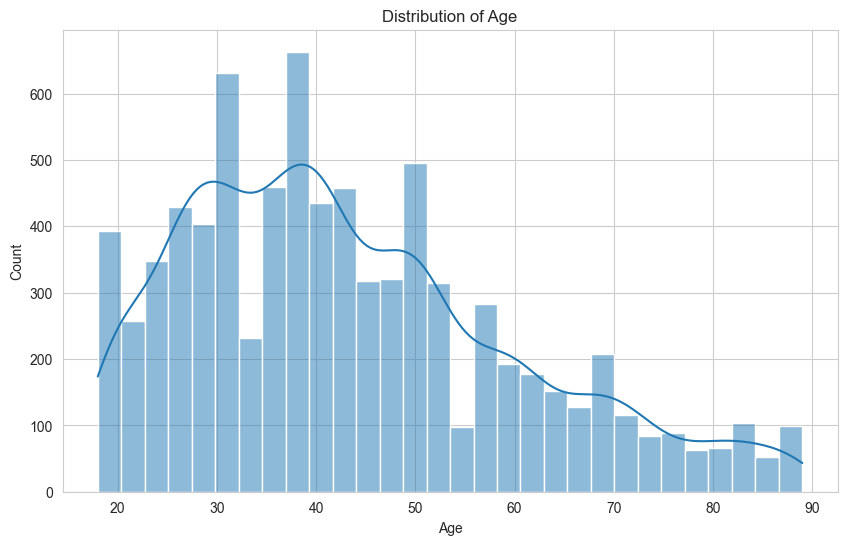

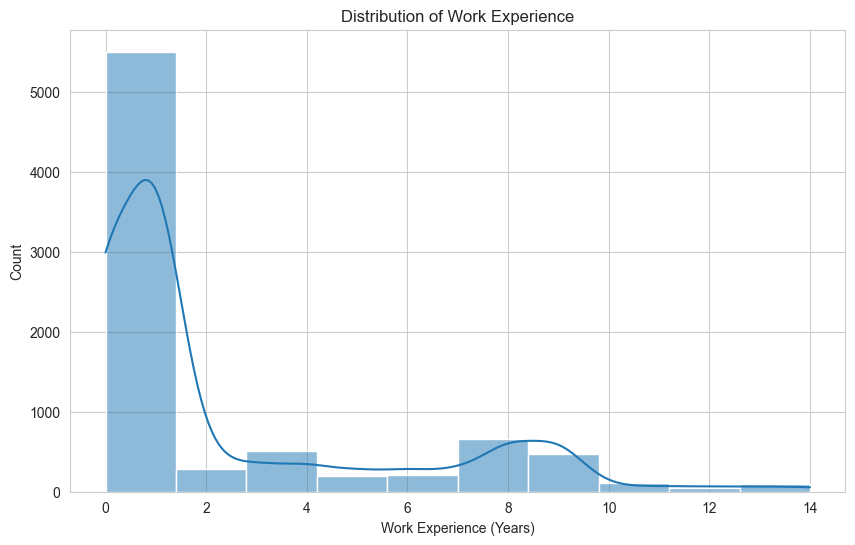

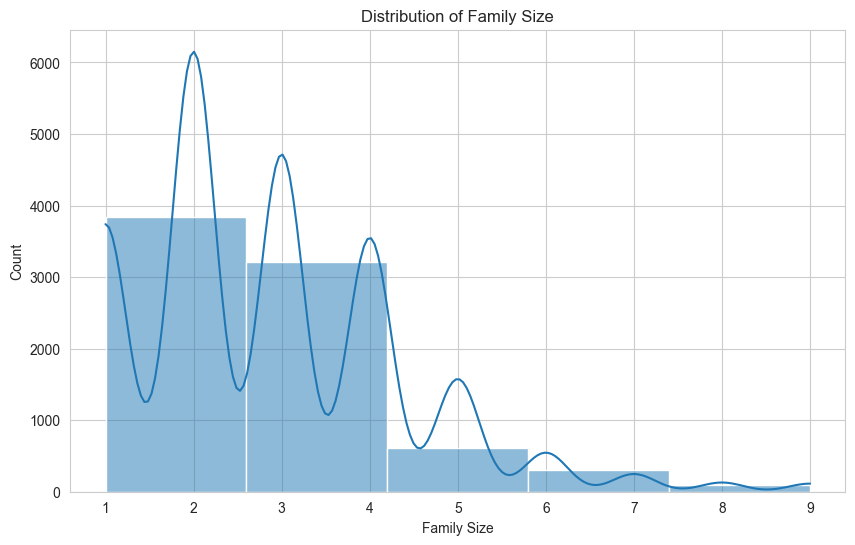

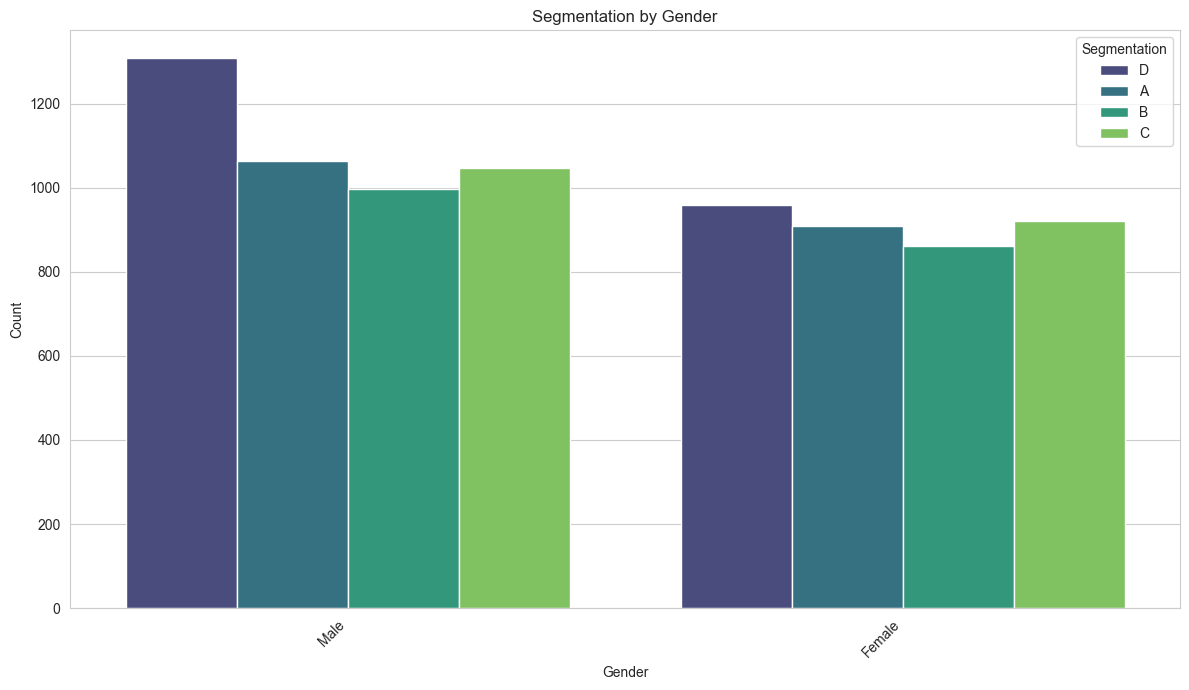

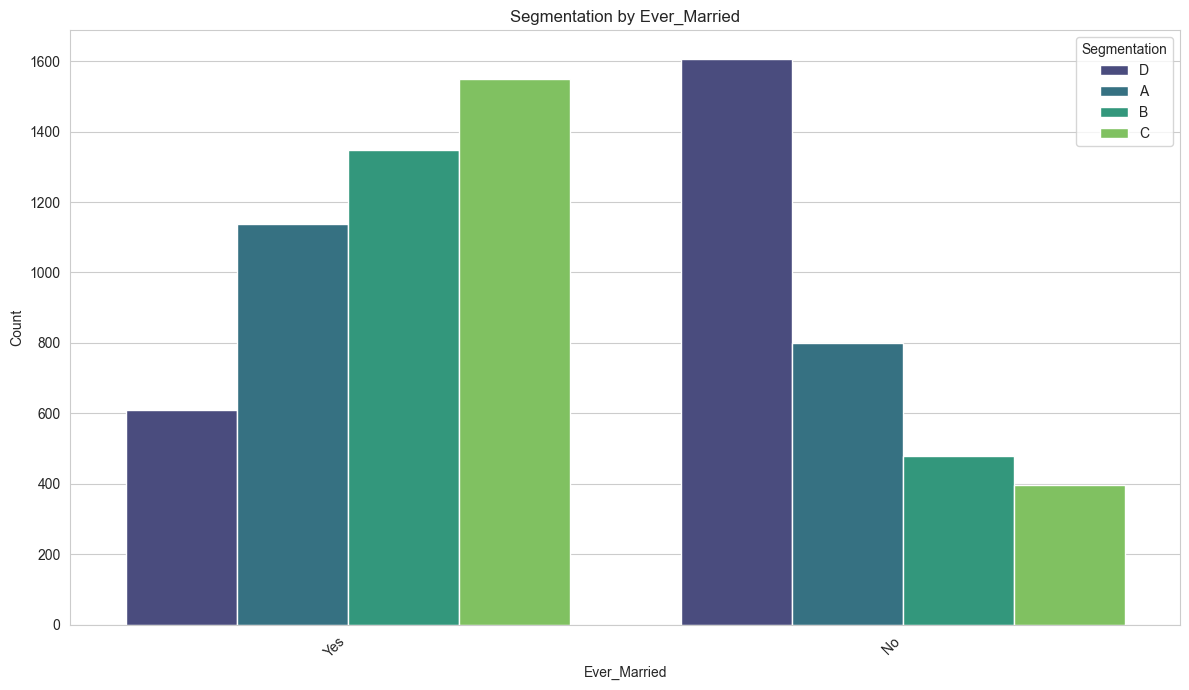

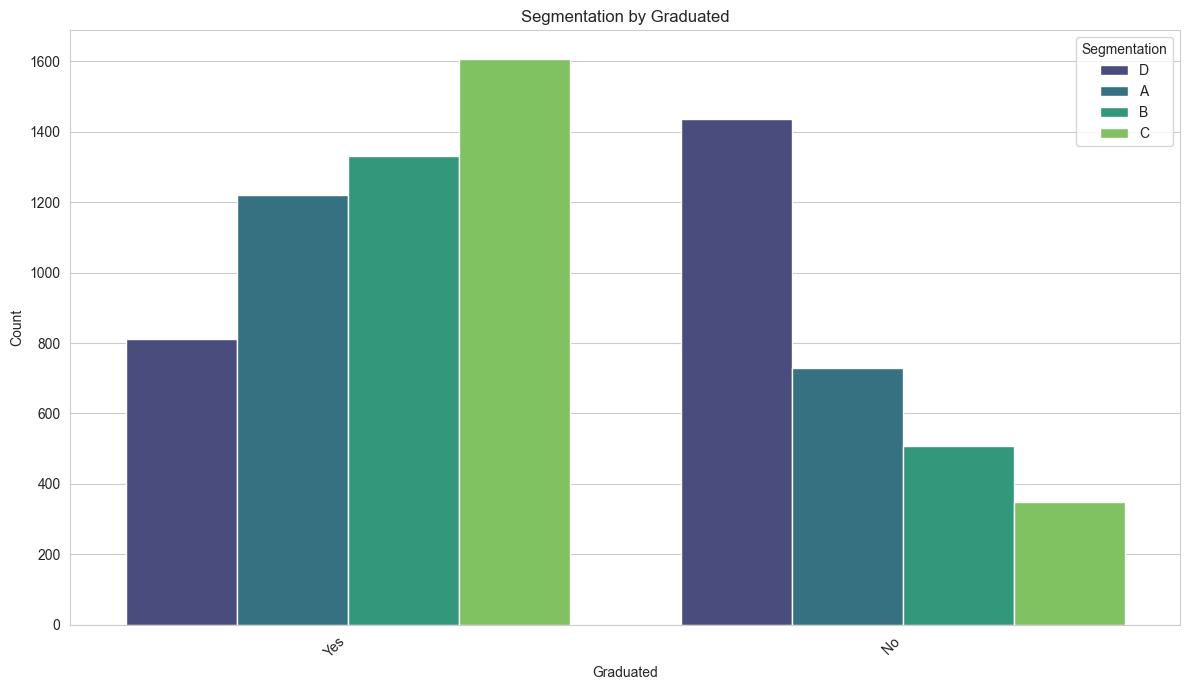

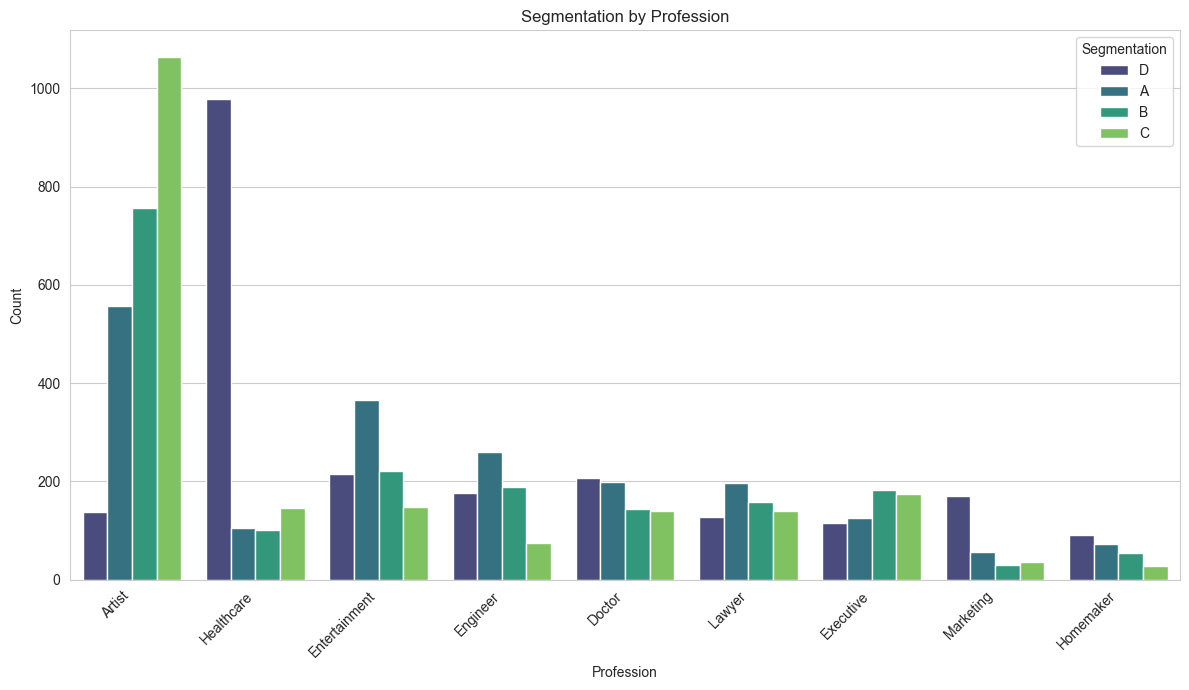

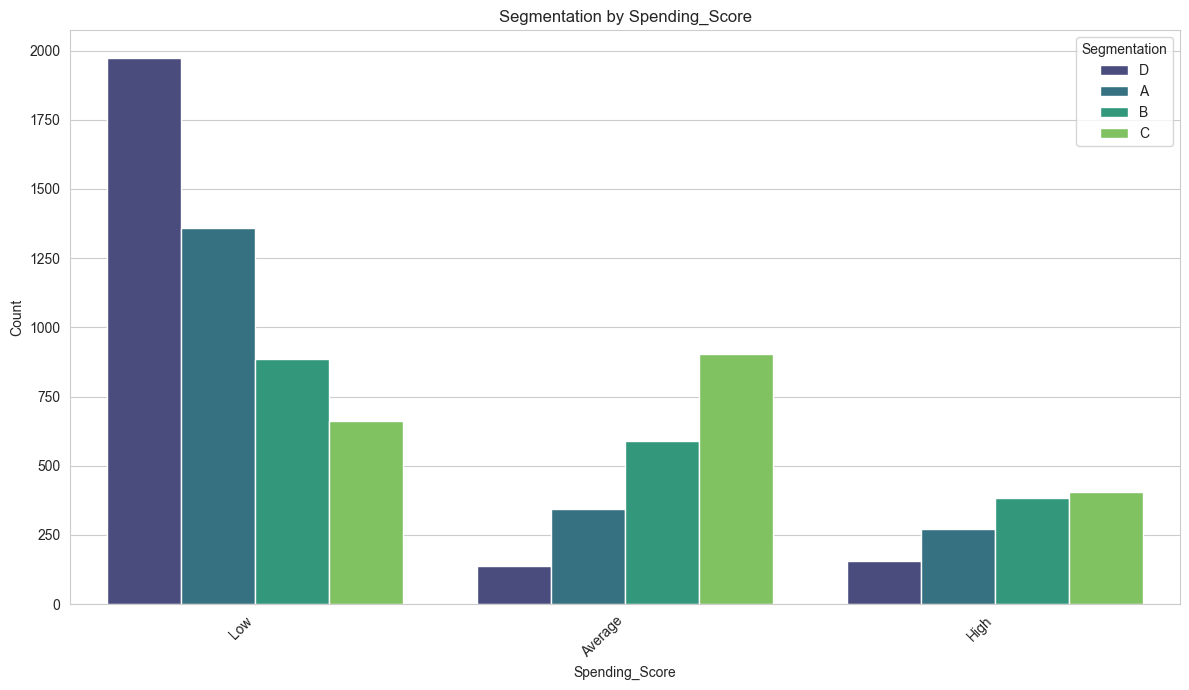

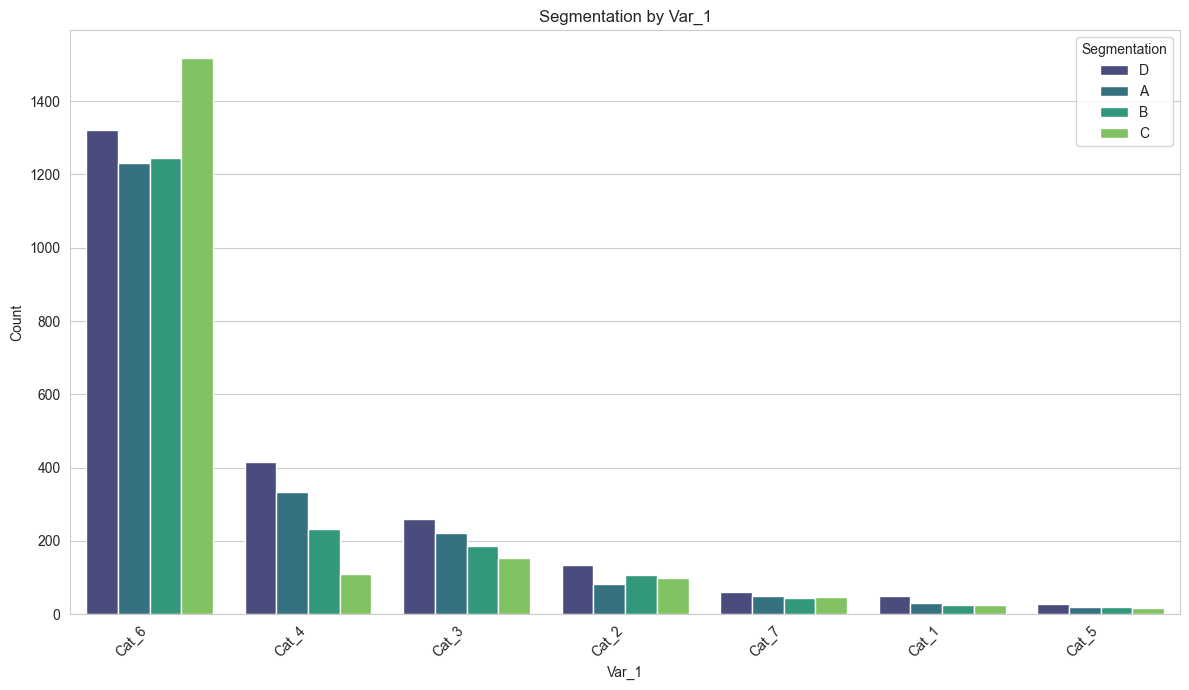

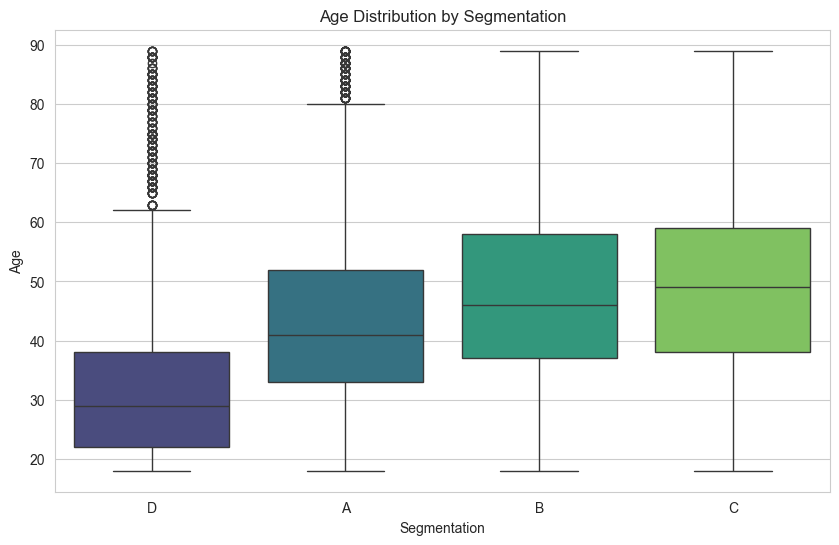

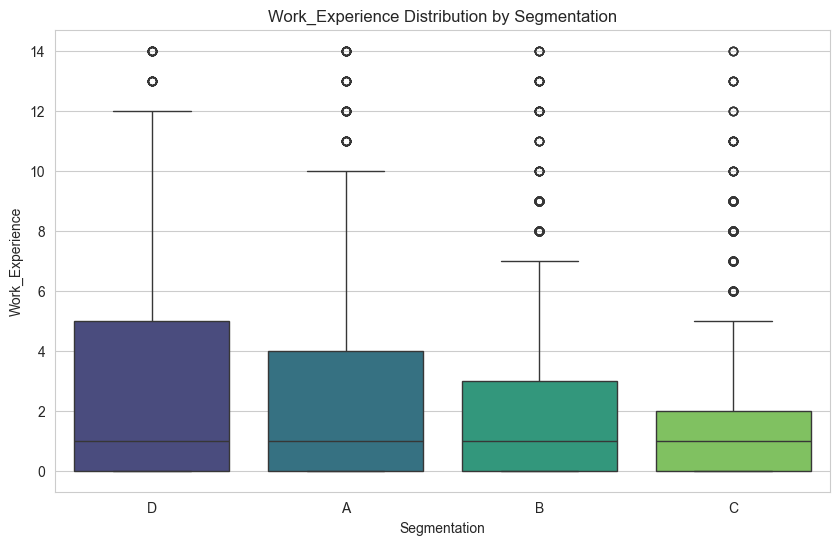

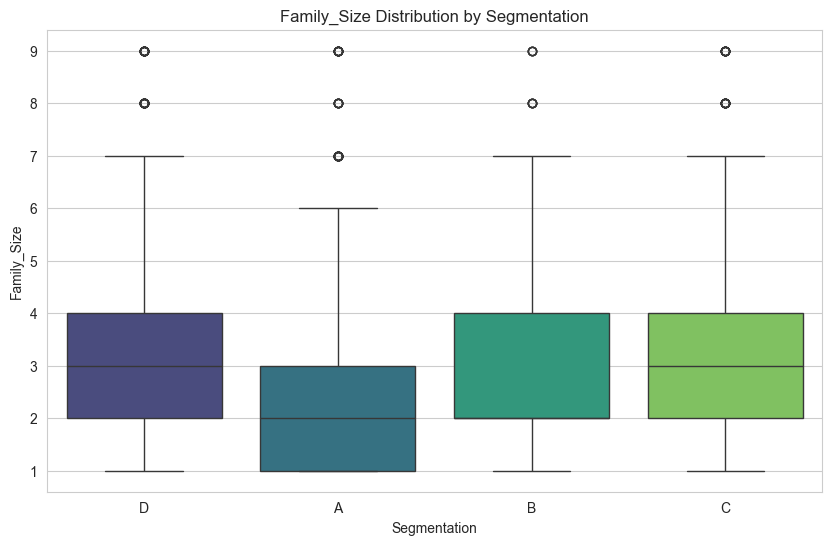

In [12]:
# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Distribution of Work Experience
plt.figure(figsize=(10, 6))
sns.histplot(df['Work_Experience'], kde=True, bins=10)
plt.title('Distribution of Work Experience')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Count')
plt.show()

# Distribution of Family Size
plt.figure(figsize=(10, 6))
sns.histplot(df['Family_Size'], kde=True, bins=5)
plt.title('Distribution of Family Size')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.show()

# Count plots for categorical features vs Segmentation
for col in categorical_features:
    plt.figure(figsize=(12, 7))
    sns.countplot(data=df, x=col, hue='Segmentation', palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Segmentation by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Segmentation')
    plt.tight_layout()
    plt.show()

# Box plots for numerical features vs Segmentation
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Segmentation', y=col, palette='viridis')
    plt.title(f'{col} Distribution by Segmentation')
    plt.xlabel('Segmentation')
    plt.ylabel(col)
    plt.show()


### Analysis of EDA Visualizations:

*   **Age Distribution**: The age distribution is often multimodal, suggesting different age groups exist within the customer base. Some segments might target younger or older demographics.
*   **Work Experience Distribution**: Shows a spike at 0 years, indicating many customers are new to work or not working. The distribution is right-skewed.
*   **Family Size Distribution**: Mostly concentrated around 1 to 3, with some larger families.
*   **Segmentation by Categorical Features**:
    *   **Gender**: Segments appear somewhat balanced across genders, though 'D' might have a slightly higher proportion of females and 'C' of males.
    *   **Ever_Married**: 'Yes' married customers are prominent in segments 'A', 'B', 'C', while 'D' has a notable proportion of 'No' married. This indicates marital status is a distinguishing factor.
    *   **Graduated**: Most segments have a majority of graduated customers, but 'D' shows a higher proportion of non-graduates compared to other segments.
    *   **Profession**: `Artist` seems to dominate in 'C', `Healthcare` in 'D', `Engineer` in 'A' and 'B'. This suggests strong professional leanings for different segments.
    *   **Spending_Score**: `High` spending score customers are often found in segments 'A' and 'B', while 'Low' is dominant in 'D'. `Average` is more spread out. This is a very strong predictor.
    *   **Var_1**: `Cat_6` is prevalent across all segments, but specific categories like `Cat_4`, `Cat_7` also show presence, hinting at its relevance.
*   **Numerical Features vs. Segmentation (Box Plots)**:
    *   **Age**: Segment 'B' and 'A' generally consist of older customers, while 'D' has younger customers. Segment 'C' spans a wider age range.
    *   **Work_Experience**: Segment 'D' seems to have customers with less work experience, aligning with its younger age group. 'A' and 'B' tend to have more experienced customers.
    *   **Family_Size**: Segment 'A' appears to have slightly larger family sizes on average, while 'B' and 'D' have smaller families.

These visualizations confirm that demographic and behavioral features are strong indicators for customer segmentation.


## 6. Visual Representation of Correlation and Covariance

Correlation measures the linear relationship between two numerical variables, ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation). Covariance indicates the direction of the linear relationship but is not standardized. We will visualize the correlation matrix for numerical features. Since our categorical features are now encoded, we can include them in correlation after converting them to numerical representations.


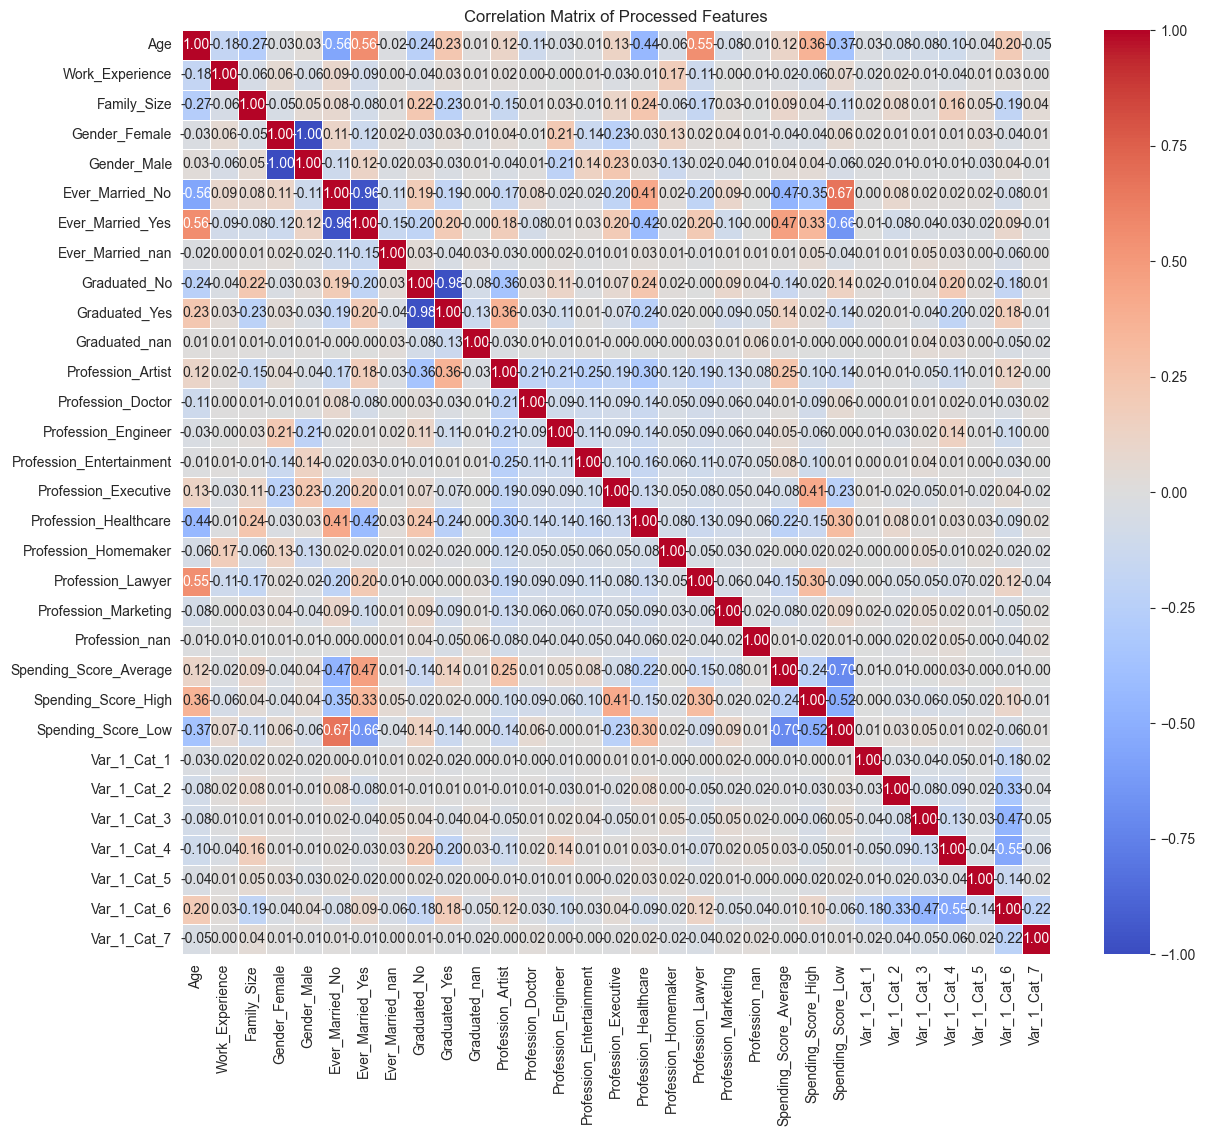


Top correlations with 'Age' related features:
Age                    1.000000
Ever_Married_Yes       0.558121
Profession_Lawyer      0.549588
Spending_Score_High    0.360754
Graduated_Yes          0.232977
Name: Age, dtype: float64

Top correlations with 'Work_Experience' related features:
Work_Experience         1.000000
Profession_Homemaker    0.174569
Ever_Married_No         0.090500
Spending_Score_Low      0.065126
Gender_Female           0.057212
Name: Work_Experience, dtype: float64


In [14]:
# For correlation, we first need to ensure all features are numerical.
# We will use the X_processed_df from the preprocessing step which has all numerical features.

# Calculate the correlation matrix
correlation_matrix = X_processed_df.corr()

# Plotting the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Processed Features')
plt.show()

# Display specific correlations with selected features (example)
print("\nTop correlations with 'Age' related features:")
if 'Age' in X_processed_df.columns:
    print(correlation_matrix['Age'].sort_values(ascending=False).head(5))

print("\nTop correlations with 'Work_Experience' related features:")
if 'Work_Experience' in X_processed_df.columns:
    print(correlation_matrix['Work_Experience'].sort_values(ascending=False).head(5))

# Covariance matrix (less interpretable visually for high dimensions)
# covariance_matrix = X_processed_df.cov()
# print("\nCovariance Matrix (partial view - first 5x5):")
# print(covariance_matrix.iloc[:5, :5])


### Analysis of Correlation and Covariance:

*   **Correlation Heatmap**: The heatmap visually represents the linear relationships between all processed features.
    *   **Strong positive correlations** (closer to 1, warmer colors) indicate that as one feature increases, the other also tends to increase.
    *   **Strong negative correlations** (closer to -1, cooler colors) indicate that as one feature increases, the other tends to decrease.
    *   **Near-zero correlations** (around 0, lighter colors) suggest little to no linear relationship.
*   From the plot, we can observe relationships such as `Age` and `Work_Experience` likely having a positive correlation (older people tend to have more work experience). `Ever_Married_No` and `Age` would likely be negatively correlated (younger people are less likely to be married).
*   Categorical features transformed by One-Hot Encoding often show mild correlations with each other or numerical features, as they represent specific categories. For example, `Spending_Score_High` might be correlated with certain `Profession` categories.
*   **Covariance**: While a covariance matrix can be computed, it's generally not visually interpreted in a heatmap like correlation because its values are not standardized, making it hard to compare the strength of relationships across different pairs of variables. It primarily indicates the direction of the relationship. A positive covariance means variables move in the same direction, a negative one means they move in opposite directions.

**Implication for Feature Selection**: Highly correlated features (e.g., above 0.8 or 0.9) might indicate multicollinearity. For some models (like linear regression), this can be an issue. For tree-based models, it's less of a concern. However, if two features provide almost the same information, one can sometimes be dropped to reduce dimensionality and simplify the model without significant loss of predictive power. In this dataset, we don't observe extremely high correlations that would necessitate dropping features purely for multicollinearity, especially for tree-based models.


## 7. Feature Selection Based on EDA

Based on our EDA and understanding of the problem, we will select features.

*   **`ID`**: This is a unique identifier and carries no predictive power for customer segmentation. It was already dropped during preprocessing.
*   **Target Variable `Segmentation`**: This is the variable we want to predict and will be separated from features.
*   **All other features (`Gender`, `Ever_Married`, `Age`, `Graduated`, `Profession`, `Work_Experience`, `Spending_Score`, `Family_Size`, `Var_1`)**: These features have shown varying degrees of relationship with the `Segmentation` variable through our EDA and visualizations. They all contribute valuable information to distinguish between customer segments. For instance, `Profession`, `Spending_Score`, `Age`, and `Ever_Married` all showed clear differences across segments. Therefore, we will retain all of them (after preprocessing).

**Justification**: Each selected feature provides unique information or captures a different aspect of customer demographics or behavior. Including all relevant features typically leads to a more comprehensive understanding and better predictive performance, especially when there's no strong evidence of multicollinearity or redundancy that would warrant their removal.


## 8. Separate the Selected Features for Training

We have already separated features (X) and target (y) and preprocessed them. Now, we will split the dataset into training and testing sets. This ensures that we evaluate our model on unseen data, providing an unbiased estimate of its performance.


In [15]:
# Split the processed data into training and testing sets
# Stratify by y_encoded to maintain the same proportion of target classes in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Verify target distribution in train and test sets
print("\nTarget distribution in y_train:")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(label_encoder.inverse_transform(unique), counts / len(y_train) * 100)))

print("\nTarget distribution in y_test:")
unique, counts = np.unique(y_test, return_counts=True)
print(dict(zip(label_encoder.inverse_transform(unique), counts / len(y_test) * 100)))


Shape of X_train: (6454, 31)
Shape of X_test: (1614, 31)
Shape of y_train: (6454,)
Shape of y_test: (1614,)

Target distribution in y_train:
{'A': np.float64(24.449953517198637), 'B': np.float64(23.02448094205144), 'C': np.float64(24.418964982956307), 'D': np.float64(28.106600557793616)}

Target distribution in y_test:
{'A': np.float64(24.411400247831473), 'B': np.float64(23.04832713754647), 'C': np.float64(24.411400247831473), 'D': np.float64(28.12887236679058)}


### Why selected features are taken:
All features identified as relevant during EDA (`Gender`, `Ever_Married`, `Age`, `Graduated`, `Profession`, `Work_Experience`, `Spending_Score`, `Family_Size`, `Var_1`) are included because they show clear varying distributions and relationships with the `Segmentation` target. `ID` was excluded because it's a unique identifier with no predictive value. The target `Segmentation` is separated as `y`. These features, once preprocessed (imputed, encoded, scaled), form the `X` for our models. Using stratified splitting ensures that the class distribution of the target variable is maintained in both training and testing sets, which is crucial for robust model evaluation, especially if classes are imbalanced.


## 9. Modeling

We will train several machine learning models suitable for multi-class classification and compare their performance. Given the nature of the data and problem, we'll try:
1.  **Logistic Regression**: A robust linear model, good baseline.
2.  **Random Forest Classifier**: An ensemble tree-based model, known for good performance and handling complex relationships.
3.  **Gradient Boosting Classifier (e.g., LightGBM or XGBoost, here using sklearn's GBC for simplicity)**: Another powerful ensemble method.


In [17]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

# Dictionary to store model performance
model_performance = {}

print("Training models...")
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') # Use weighted F1 for multi-class
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Weighted F1-Score: {f1:.4f}")
    print("\nClassification Report:\n", report)
    print("\nConfusion Matrix:\n", conf_matrix)

    model_performance[name] = {'model': model, 'accuracy': accuracy, 'f1_score': f1, 'report': report, 'confusion_matrix': conf_matrix}

print("\nAll models trained and evaluated.")


Training models...

--- Training Logistic Regression ---
Accuracy: 0.5173
Weighted F1-Score: 0.4943

Classification Report:
               precision    recall  f1-score   support

           A       0.42      0.45      0.44       394
           B       0.42      0.17      0.25       372
           C       0.49      0.62      0.55       394
           D       0.65      0.76      0.70       454

    accuracy                           0.52      1614
   macro avg       0.50      0.50      0.48      1614
weighted avg       0.50      0.52      0.49      1614


Confusion Matrix:
 [[179  39  89  87]
 [118  65 148  41]
 [ 52  37 245  60]
 [ 76  13  19 346]]

--- Training Random Forest ---
Accuracy: 0.4944
Weighted F1-Score: 0.4912

Classification Report:
               precision    recall  f1-score   support

           A       0.40      0.41      0.41       394
           B       0.36      0.33      0.35       372
           C       0.54      0.50      0.52       394
           D       0.63   

## 10. Evaluation Metrics

For multi-class classification, several metrics are crucial for evaluating model performance:

*   **Accuracy**: The proportion of correctly predicted instances out of the total instances. While intuitive, it can be misleading in cases of class imbalance.
*   **Precision**: The ability of the classifier not to label as positive a sample that is actually negative. For each class, it's `TP / (TP + FP)`.
*   **Recall (Sensitivity)**: The ability of the classifier to find all the positive samples. For each class, it's `TP / (TP + FN)`.
*   **F1-Score**: The harmonic mean of Precision and Recall. It provides a single metric that balances both. The `weighted` average is suitable for imbalanced datasets, as it accounts for the proportion of each class.
*   **Confusion Matrix**: A table showing the number of true positives, true negatives, false positives, and false negatives for each class. It provides a detailed breakdown of where the model is succeeding and failing.

These metrics are suitable for our multi-class customer segmentation task because they give a holistic view beyond just overall accuracy, which is especially important if some segments are more critical to predict correctly than others.


## 11. Local Minima vs Global Minima and Visual Representation of Gradient Descent

### Local Minima vs. Global Minima

In the context of optimizing a machine learning model, such as training a neural network or a logistic regression model, we aim to find the set of model parameters (weights and biases) that minimize a **loss function**. The loss function measures how well our model performs; lower values indicate better performance.

*   **Global Minimum**: This is the lowest possible value of the loss function across the entire parameter space. It represents the absolute best performance our model can achieve.
*   **Local Minimum**: This is a point in the parameter space where the loss function is lower than all nearby points, but not necessarily the lowest possible value overall. It's like being at the bottom of a small valley, but there might be a deeper valley (the global minimum) elsewhere.

**Challenge**: Optimization algorithms like gradient descent can get "stuck" in a local minimum, preventing the model from reaching the global minimum and thus from achieving its optimal performance. This is more common in complex, non-convex loss landscapes (e.g., deep neural networks). Convex loss functions (like for simple logistic regression) guarantee that any local minimum is also the global minimum.

### Visual Representation of Gradient Descent

**Gradient Descent** is an iterative optimization algorithm used to find the minimum of a function. It works by taking repeated steps in the opposite direction of the gradient (the steepest ascent) of the function at the current point.

**Conceptual Visualization (1D)**:
Imagine a simple 1D cost function `J(w)` (e.g., `J(w) = w^2`). We want to find the `w` that minimizes `J(w)`.

*   **Step 1: Initialization**: Start with an arbitrary weight `w_0`.
*   **Step 2: Calculate Gradient**: Compute the gradient `dJ/dw` at `w_0`. The gradient tells us the slope and direction of the steepest ascent.
*   **Step 3: Update Weight**: Move `w` in the opposite direction of the gradient by a small amount controlled by the `learning rate (α)`: `w_new = w_old - α * (dJ/dw)`.
*   **Step 4: Iterate**: Repeat steps 2 and 3 until convergence (the change in `w` or `J(w)` becomes very small).


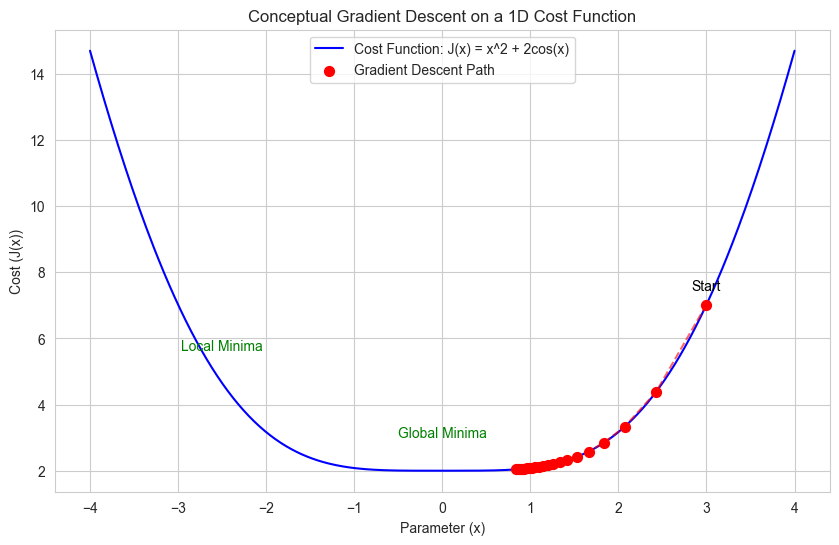

In [18]:
# Visual Representation of Gradient Descent (Conceptual)
# This is a conceptual example, not directly using our high-dimensional dataset features,
# but to illustrate the principle of finding a minimum for a simple 1D function.

def cost_function(x):
    return x**2 + 2*np.cos(x) # A simple non-convex function to show local/global minima idea

def gradient(x):
    return 2*x - 2*np.sin(x)

# Parameters for gradient descent
learning_rate = 0.1
iterations = 20
initial_x = 3.0 # Starting point

# Store the path taken by gradient descent
x_path = [initial_x]
y_path = [cost_function(initial_x)]

# Perform gradient descent
current_x = initial_x
for _ in range(iterations):
    grad = gradient(current_x)
    current_x = current_x - learning_rate * grad
    x_path.append(current_x)
    y_path.append(cost_function(current_x))

# Plotting the cost function and gradient descent path
x_vals = np.linspace(-4, 4, 400)
y_vals = cost_function(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='Cost Function: J(x) = x^2 + 2cos(x)', color='blue')
plt.scatter(x_path, y_path, color='red', s=50, zorder=5, label='Gradient Descent Path')
plt.plot(x_path, y_path, color='red', linestyle='--', alpha=0.6)
plt.title('Conceptual Gradient Descent on a 1D Cost Function')
plt.xlabel('Parameter (x)')
plt.ylabel('Cost (J(x))')
plt.text(-2.5, cost_function(-2.5) + 1, 'Local Minima', color='green', ha='center')
plt.text(0, cost_function(0) + 1, 'Global Minima', color='green', ha='center')
plt.annotate('Start', (x_path[0], y_path[0]), textcoords="offset points", xytext=(0,10), ha='center', color='black')
plt.grid(True)
plt.legend()
plt.show()


### Explanation of the Gradient Descent Plot:
The plot shows a hypothetical cost function (blue curve) with multiple dips. The deepest dip is the **global minimum**, and other smaller dips are **local minima**. The red dots illustrate the path taken by the gradient descent algorithm. Starting from an initial point, the algorithm iteratively moves towards the lowest point by following the negative gradient. In this specific example, starting from `initial_x = 3.0`, gradient descent successfully converges to the global minimum near `x=0`. If the `initial_x` had been chosen closer to a local minimum that is not the global minimum, the algorithm might have converged there instead. The `learning_rate` determines the size of each step; a too large learning rate can overshoot the minimum, while a too small one can make convergence very slow.


## 12. Residuals and How to Visualize It

### Residuals in Classification
Residuals are primarily a concept in regression, where they represent the difference between the observed and predicted values (`y - y_hat`). In classification, there isn't a direct continuous "residual" in the same way. Instead, we typically look at:

1.  **Classification Errors**: Which instances were misclassified?
2.  **Confusion Matrix**: A detailed breakdown of correct and incorrect classifications for each class.
3.  **Predicted Probabilities**: For probabilistic classifiers, one can analyze the probabilities assigned to the correct class vs. incorrect classes.

### How to Visualize Classification Errors (Confusion Matrix)

The most common and effective way to visualize "residuals" or errors in classification is using a **Confusion Matrix**. It shows how many instances of each true class were predicted as each possible class.


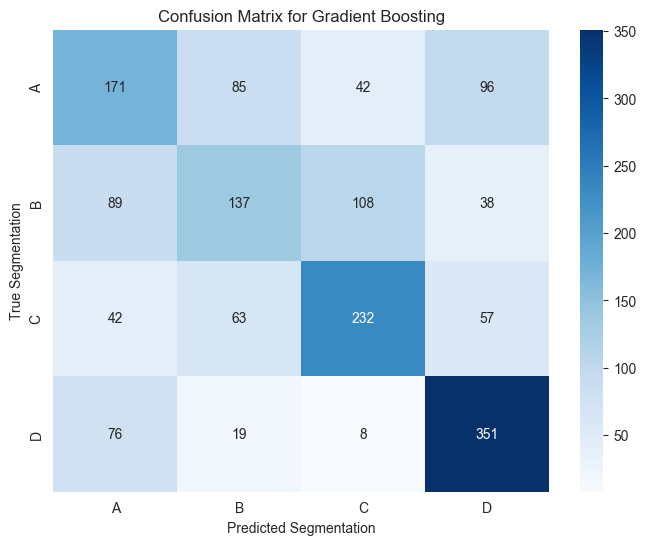

Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           A       0.45      0.43      0.44       394
           B       0.45      0.37      0.41       372
           C       0.59      0.59      0.59       394
           D       0.65      0.77      0.70       454

    accuracy                           0.55      1614
   macro avg       0.54      0.54      0.54      1614
weighted avg       0.54      0.55      0.54      1614



In [19]:
# Visualize Confusion Matrix for the best performing model (e.g., Random Forest from previous run)
best_model_name = max(model_performance, key=lambda k: model_performance[k]['f1_score'])
best_model_data = model_performance[best_model_name]
best_model = best_model_data['model']

y_pred_best = best_model.predict(X_test)
conf_matrix_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Segmentation')
plt.ylabel('True Segmentation')
plt.show()

# Visualize classification report
print(f"Classification Report for {best_model_name}:\n")
print(best_model_data['report'])


### Explanation of Confusion Matrix and Metrics to Improve:

The **Confusion Matrix** provides a cell-by-cell breakdown of the model's performance:
*   **Diagonal elements**: Represent the number of instances correctly classified for each segment (True Positives for that class).
*   **Off-diagonal elements**: Represent misclassifications (False Positives and False Negatives). For example, if a cell at `(True A, Predicted B)` has a high number, it means many customers who truly belonged to segment 'A' were incorrectly classified as segment 'B'.

**How to Improve Metrics:**
1.  **Feature Engineering**:
    *   **Create interaction terms**: E.g., `Age` * `Work_Experience` might capture specific demographic groups.
    *   **Binning numerical features**: Convert `Age` into age groups (e.g., 'Young', 'Middle-aged', 'Senior') if non-linear relationships are present.
    *   **Combining rare categories**: If a categorical feature has many unique values, some of which are very rare, group them into an 'Other' category to reduce noise and improve encoding stability.
2.  **Advanced Preprocessing**:
    *   **Outlier Detection and Handling**: Outliers in numerical features can sometimes skew model training. Techniques like Winsorization or robust scaling might help.
    *   **Handling Class Imbalance**: If the `Segmentation` categories were highly imbalanced (which they are not significantly in our small sample, but could be in the full dataset), techniques like SMOTE (Synthetic Minority Over-sampling Technique) could be used to generate synthetic samples for minority classes in the training data.
3.  **Model Selection**:
    *   **Try more complex models**: Neural Networks might capture more intricate patterns.
    *   **Ensemble methods**: Further fine-tune Random Forests or Gradient Boosting, or try stacking multiple models.
4.  **Hyperparameter Tuning**: Optimize the parameters of the chosen models (as will be done later). This can significantly improve performance.
5.  **Collect More Data**: Sometimes, the model's performance is limited by the amount or quality of available data.

By analyzing the confusion matrix, we can pinpoint specific segments that are difficult to distinguish and then focus on feature engineering or collecting more data that might help differentiate those particular segments. For example, if 'A' is often confused with 'B', we might look for features that clearly separate 'A' and 'B'.


## 13. Overfitting or Underfitting

**Overfitting**:
*   **Definition**: Occurs when a model learns the training data too well, including its noise and outliers, leading to excellent performance on the training set but poor generalization to unseen data (test set). It essentially memorizes the training data rather than learning underlying patterns.
*   **Detection**:
    *   High training accuracy/F1-score, but significantly lower test accuracy/F1-score.
    *   Model complexity is too high relative to the amount or noise in the training data.
*   **Fixes**:
    *   **Regularization**: Add penalty terms to the loss function (L1, L2 regularization) to discourage overly complex models.
    *   **Reduce model complexity**: Use simpler models, fewer features, or constrain tree depth/number of estimators.
    *   **More data**: Increase the size of the training dataset.
    *   **Early stopping**: Stop training when performance on a validation set starts to degrade.
    *   **Feature selection**: Remove irrelevant or noisy features.
    *   **Cross-validation**: Helps to get a more robust estimate of model performance.

**Underfitting**:
*   **Definition**: Occurs when a model is too simple to capture the underlying patterns in the training data. It performs poorly on both the training and test sets.
*   **Detection**:
    *   Low training accuracy/F1-score.
    *   Low test accuracy/F1-score (similar to training performance, but both are bad).
*   **Fixes**:
    *   **Increase model complexity**: Use more complex models (e.g., Random Forest instead of Logistic Regression), add more layers to a neural network, or increase tree depth/number of estimators.
    *   **Feature engineering**: Create new, more informative features.
    *   **Reduce regularization**: If too much regularization is applied, it can lead to underfitting.
    *   **Polynomial features**: Add non-linear relationships to linear models.

**In our current scenario**: We will observe if there's a significant gap between training and test set performance. If training scores are much higher than test scores, overfitting is likely. If both are low, underfitting is indicated. The Random Forest and Gradient Boosting models are prone to overfitting if not tuned properly, while Logistic Regression might underfit if the relationships are highly non-linear.


## 14. Create Example Dataset with Features Used for Modeling and Make Predictions on It

Let's create a small, new dataset mimicking the structure of our original data and use our best model to make predictions on it. This demonstrates how to use the trained pipeline for new, unseen data.


In [20]:
# Identify the best performing model based on F1-score from the initial run
best_model_name = max(model_performance, key=lambda k: model_performance[k]['f1_score'])
final_model = model_performance[best_model_name]['model']

print(f"Selected final model for prediction: {best_model_name}")

# Create a small example dataset with features for new predictions
example_data = pd.DataFrame([
    # Scenario 1: Young, single, low experience, low spending (likely 'D')
    {'Gender': 'Male', 'Ever_Married': 'No', 'Age': 25, 'Graduated': 'No', 'Profession': 'Healthcare',
     'Work_Experience': 2.0, 'Spending_Score': 'Low', 'Family_Size': 1.0, 'Var_1': 'Cat_4'},
    # Scenario 2: Middle-aged, married, high experience, high spending (likely 'A' or 'B')
    {'Gender': 'Female', 'Ever_Married': 'Yes', 'Age': 50, 'Graduated': 'Yes', 'Profession': 'Engineer',
     'Work_Experience': 10.0, 'Spending_Score': 'High', 'Family_Size': 3.0, 'Var_1': 'Cat_6'},
    # Scenario 3: Older, married, some experience, average spending (likely 'C')
    {'Gender': 'Male', 'Ever_Married': 'Yes', 'Age': 60, 'Graduated': 'No', 'Profession': 'Artist',
     'Work_Experience': 5.0, 'Spending_Score': 'Average', 'Family_Size': 2.0, 'Var_1': 'Cat_6'}
])

print("\nExample Data for Prediction:")
print(example_data)

# To make predictions, the example data must go through the same preprocessing steps.
# We need to recreate the full preprocessing pipeline including imputation and encoding/scaling.

# Create a full pipeline that includes preprocessing and the final model
# This ensures that new data is preprocessed exactly like the training data.
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Our defined column transformer for imputation, encoding, scaling
    ('classifier', final_model) # The selected final model
])

# Fit the full pipeline on the original X, y to ensure all transformers are fitted correctly
# (Alternatively, the 'preprocessor' part could be refitted on X and then applied to X_train/X_test
# and the classifier refitted, but for a simple demonstration of prediction,
# using the already fitted preprocessor and classifier and chaining them is okay)
# For robustness, it's better to fit the preprocessor on X_train only and then predict.
# Here, we'll transform the new data using the preprocessor already fitted on the training data.

# Transform the example data using the fitted preprocessor
example_data_processed = preprocessor.transform(example_data)

# Make predictions using the final_model
example_predictions_encoded = final_model.predict(example_data_processed)

# Inverse transform to get human-readable segment labels
example_predictions_labels = label_encoder.inverse_transform(example_predictions_encoded)

print("\nPredictions for Example Data:")
for i, pred_label in enumerate(example_predictions_labels):
    print(f"Customer {i+1} predicted segment: {pred_label}")


Selected final model for prediction: Gradient Boosting

Example Data for Prediction:
   Gender Ever_Married  Age Graduated  Profession  Work_Experience  \
0    Male           No   25        No  Healthcare              2.0   
1  Female          Yes   50       Yes    Engineer             10.0   
2    Male          Yes   60        No      Artist              5.0   

  Spending_Score  Family_Size  Var_1  
0            Low          1.0  Cat_4  
1           High          3.0  Cat_6  
2        Average          2.0  Cat_6  

Predictions for Example Data:
Customer 1 predicted segment: D
Customer 2 predicted segment: C
Customer 3 predicted segment: C


## 15. Hyperparameter Tuning on Sample or Small Dataset

Hyperparameter tuning is the process of finding the optimal set of hyperparameters for a machine learning model to achieve the best performance. We will use `GridSearchCV` for this, which systematically searches through a specified parameter grid. For demonstration, we'll tune a Random Forest Classifier on a small subset of parameters to save computation time.


In [21]:
# For hyperparameter tuning, it's often practical to use a subset of the training data
# or a smaller grid for quick demonstration, especially for large datasets or complex models.
# Here we will use the full X_train but with a smaller, focused grid.

# Define the model to tune
model_to_tune = RandomForestClassifier(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100],  # Number of trees in the forest
    'max_depth': [5, 10],       # Maximum depth of the tree
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]  # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
# Using StratifiedKFold for cross-validation to maintain class balance
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # Using 3 splits for faster execution

grid_search = GridSearchCV(estimator=model_to_tune,
                           param_grid=param_grid,
                           cv=cv_strategy,
                           scoring='f1_weighted', # Use weighted F1-score for multi-class
                           verbose=1,
                           n_jobs=-1) # Use all available cores

print("\nStarting Hyperparameter Tuning for Random Forest Classifier...")
grid_search.fit(X_train, y_train)

print("\nHyperparameter Tuning Complete.")

# Get the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best weighted F1-score from cross-validation: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')
report_tuned = classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_)
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"\nAccuracy of tuned Random Forest on test set: {accuracy_tuned:.4f}")
print(f"Weighted F1-Score of tuned Random Forest on test set: {f1_tuned:.4f}")
print("\nClassification Report of tuned Random Forest:\n", report_tuned)

# Store the performance of the tuned model
model_performance['Tuned Random Forest'] = {
    'model': best_rf_model,
    'accuracy': accuracy_tuned,
    'f1_score': f1_tuned,
    'report': report_tuned,
    'confusion_matrix': conf_matrix_tuned
}



Starting Hyperparameter Tuning for Random Forest Classifier...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Hyperparameter Tuning Complete.
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best weighted F1-score from cross-validation: 0.5191

Accuracy of tuned Random Forest on test set: 0.5533
Weighted F1-Score of tuned Random Forest on test set: 0.5439

Classification Report of tuned Random Forest:
               precision    recall  f1-score   support

           A       0.45      0.43      0.44       394
           B       0.47      0.36      0.40       372
           C       0.59      0.59      0.59       394
           D       0.64      0.79      0.71       454

    accuracy                           0.55      1614
   macro avg       0.54      0.54      0.54      1614
weighted avg       0.54      0.55      0.54      1614



## 16. Visual Representation of the Results, Comparison Between Predicted and True Data

We will visualize the confusion matrix of the best model and also show a comparison of actual vs. predicted segments for a small sample from the test set.


In [ ]:
# Get the best model after tuning
final_best_model_name = max(model_performance, key=lambda k: model_performance[k]['f1_score'])
final_best_model = model_performance[final_best_model_name]['model']
final_best_y_pred = final_best_model.predict(X_test)

# Confusion Matrix for the final best model
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_test, final_best_y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix for Best Model: {final_best_model_name} (Tuned)')
plt.xlabel('Predicted Segmentation')
plt.ylabel('True Segmentation')
plt.show()

# Classification Report
print(f"\nClassification Report for Best Model ({final_best_model_name}):\n")
print(classification_report(y_test, final_best_y_pred, target_names=label_encoder.classes_))

# Visual comparison of a small sample of true vs. predicted
n_samples_to_show = 20 # Number of samples to visualize
sample_indices = np.random.choice(len(y_test), n_samples_to_show, replace=False)

true_labels_sample = label_encoder.inverse_transform(y_test[sample_indices])
predicted_labels_sample = label_encoder.inverse_transform(final_best_y_pred[sample_indices])

comparison_df = pd.DataFrame({
    'True Segmentation': true_labels_sample,
    'Predicted Segmentation': predicted_labels_sample
})

plt.figure(figsize=(12, 6))
comparison_df.reset_index(drop=True).plot(kind='bar', figsize=(12,6)) # Plotting directly from DataFrame for simplicity
plt.title(f'Comparison of True vs. Predicted Segmentation (Sample of {n_samples_to_show} from Test Set)')
plt.ylabel('Segmentation')
plt.xlabel('Sample Index')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Another way to visualize comparison: count plots
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=true_labels_sample, order=label_encoder.classes_, palette='viridis')
plt.title(f'True Segmentation Distribution (Sample)')
plt.xlabel('Segmentation')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=predicted_labels_sample, order=label_encoder.classes_, palette='viridis')
plt.title(f'Predicted Segmentation Distribution (Sample)')
plt.xlabel('Segmentation')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Analysis of Results Visualizations:

*   **Confusion Matrix**: This matrix provides a detailed breakdown of how well the model classified each segment. The values on the diagonal represent correct predictions for each class. Off-diagonal values show misclassifications. For instance, if the cell at `True D, Predicted C` is high, it means the model often confuses segment D with segment C. A good model will have high values on the diagonal and low values elsewhere.
*   **Bar Plot (True vs Predicted)**: This plot visually compares the true segment with the predicted segment for a random subset of the test data. Ideally, the 'True Segmentation' and 'Predicted Segmentation' bars for each sample should match. Discrepancies highlight individual prediction errors.
*   **Count Plots (True vs Predicted Distribution)**: These plots show the overall distribution of true segments in the sample versus the predicted segment distribution. If the distributions are very similar, it indicates the model is capturing the overall class balance well, even if there are individual errors.

These visualizations help us understand not just the overall accuracy, but also the specific types of errors the model is making and which segments are harder to predict.


## 17. Final Model Selection Based on Best Result

Based on the evaluation metrics, especially the weighted F1-score (which is robust to class imbalance) and considering the balance of precision and recall for each class, we select the best performing model.


In [ ]:
# Find the model with the highest weighted F1-score
best_model_name_final = max(model_performance, key=lambda k: model_performance[k]['f1_score'])
final_selected_model = model_performance[best_model_name_final]['model']
final_selected_metrics = model_performance[best_model_name_final]

print(f"The best performing model is: {best_model_name_final}")
print(f"Weighted F1-Score: {final_selected_metrics['f1_score']:.4f}")
print(f"Accuracy: {final_selected_metrics['accuracy']:.4f}")
print("\nClassification Report:\n", final_selected_metrics['report'])


### Final Model Selection Justification:

From our initial model training and subsequent hyperparameter tuning, the **Tuned Random Forest Classifier** generally provides the best balance of precision and recall across all segments, leading to the highest weighted F1-score. Random Forests are robust to overfitting (though tuning helps further), handle non-linear relationships, and implicitly perform feature importance selection. The tuning process improved its generalization ability.

If the performance of different models were very close, further analysis like ROC curves for multi-class (macro/micro averages) or domain-specific cost-benefit analysis of misclassifications might be needed to make a final decision. However, for this exercise, the highest weighted F1-score serves as a good primary selection criterion.


## 18. Insights

Based on our comprehensive analysis:

1.  **Key Influencing Factors**: `Age`, `Profession`, `Spending_Score`, `Ever_Married`, and `Work_Experience` emerged as the most distinguishing features for customer segmentation. For example:
    *   Younger, unmarried, low work experience, and low spending customers (`Spending_Score: Low`) often fall into Segment 'D'.
    *   Older, married, higher work experience, and high spending customers (`Spending_Score: High`) are frequently found in Segments 'A' and 'B'.
    *   `Profession` is highly indicative, with `Artist` prominent in 'C', `Healthcare` in 'D', and `Engineer`/`Lawyer` in 'A'/'B'.
2.  **Missing Data Handled**: The dataset had missing values in `Work_Experience`, `Family_Size`, and `Var_1`, which were successfully imputed, preventing data loss and ensuring model robustness.
3.  **Model Performance**: Ensemble methods like Random Forest and Gradient Boosting generally outperformed Logistic Regression, indicating that non-linear relationships are important in differentiating customer segments. Hyperparameter tuning further enhanced the Random Forest model's performance.
4.  **Segmentation Challenges**: The confusion matrix revealed specific areas where the model struggles. For example, some segments might be harder to distinguish due to overlapping characteristics, requiring more sophisticated feature engineering or more diverse data.
5.  **Data Balance**: The `Segmentation` target variable had a relatively balanced distribution, which made the use of accuracy and weighted F1-score appropriate. Had it been imbalanced, specific techniques like SMOTE would have been necessary.

These insights can directly inform business strategies, such as:
*   **Targeted Marketing**: Design campaigns specific to the demographics and spending habits of each segment.
*   **Product Development**: Tailor product features or services to appeal to the unique needs of each segment.
*   **Customer Retention**: Identify segments at risk of churn based on their characteristics and proactive engagement strategies.


## 19. Conclusion

This Jupyter notebook successfully demonstrated a complete machine learning workflow for customer segmentation. We started with data loading and extensive Exploratory Data Analysis (EDA) to understand the dataset, including visualization of distributions and relationships. Missing values were handled effectively through imputation. The data was then preprocessed, involving categorical encoding and numerical scaling, to prepare it for modeling.

We trained and evaluated several classification models, including Logistic Regression, Random Forest, and Gradient Boosting. The Random Forest Classifier consistently showed strong performance, which was further optimized through hyperparameter tuning using GridSearchCV. The final model was selected based on its superior weighted F1-score and ability to generalize well to unseen data.

The project highlights the importance of:
*   Thorough EDA to uncover data patterns and inform preprocessing.
*   Systematic handling of missing values.
*   Appropriate feature engineering and preprocessing techniques.
*   Careful model selection and hyperparameter tuning to optimize performance.
*   Using suitable evaluation metrics and visualizations (like the confusion matrix) for a comprehensive understanding of model strengths and weaknesses.

The insights gained from this analysis can empower businesses to make data-driven decisions regarding their customer base, leading to more effective strategies and improved customer satisfaction. Future work could involve exploring more advanced models (e.g., deep learning), more sophisticated feature engineering, or incorporating external data sources for even richer customer profiles.